# Titanic Survival Analysis

## Data Science and Data Analysis using Python Internship - Task 2

### Objective

The objective of this project is to analyze the Titanic dataset using Python. The project includes loading the dataset, cleaning missing values, exploring survival patterns, creating visualizations, and drawing meaningful conclusions.

This notebook follows the complete data analysis workflow:

**Load → Clean → Analyze → Visualize → Conclude**

## Import Required Libraries

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the Dataset

In this step, we import the Titanic dataset into Python using the Pandas library. The dataset contains passenger details such as age, gender, passenger class, fare, and survival status.

In [9]:
df = pd.read_csv("Titanic-Dataset.csv")

## Display the Dataset

The `head()` function displays the first five rows of the dataset, allowing us to understand its structure and the available features.

In [10]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Check Dataset Shape

The `shape` attribute returns the total number of rows and columns in the dataset.

In [11]:
df.shape

(891, 12)

## View Column Names

The dataset contains several features describing passenger information. Viewing the column names helps us understand what data is available for analysis.

In [12]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

## Dataset Information

The `info()` function provides a summary of the dataset, including the number of records, column names, data types, and missing values.

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


### Observation

The dataset consists of 891 records and 12 columns. Most columns contain complete data; however, the **Age**, **Cabin**, and **Embarked** columns have missing values that need to be handled before analysis.

## Checking Missing Values

Missing values can affect the accuracy of analysis and machine learning models. Therefore, we check each column for missing data.

In [14]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Observation

The dataset contains missing values in three columns:

- **Age:** 177 missing values
- **Cabin:** 687 missing values
- **Embarked:** 2 missing values

The `Age` column will be filled using the median value. Since the `Cabin` column contains a large number of missing values, it will not be used for this analysis. The missing values in the `Embarked` column will be filled using the most frequent value (mode).

## Checking Duplicate Records

Duplicate rows can lead to inaccurate analysis. We check whether the dataset contains any duplicate records.

In [15]:
df.duplicated().sum()

np.int64(0)

### Observation

The output of the `duplicated().sum()` function is **0**, indicating that there are no duplicate records in the Titanic dataset. Therefore, each passenger record is unique, and no duplicate entries need to be removed.

 ## Removing Duplicate Records

Duplicate records are removed to ensure that each passenger is represented only once in the dataset.

In [16]:
df = df.drop_duplicates()

In [17]:
df.shape

(891, 12)

### Observation

After removing duplicate records, the dataset shape remained **(891, 12)**. This confirms that the original dataset did not contain any duplicate rows.

## Handling Missing Values

The dataset contains missing values in the **Age**, **Cabin**, and **Embarked** columns.

Different strategies were used to handle these missing values:

- Missing values in the **Age** column were replaced with the **median** age because age is a numerical feature and the median is less affected by outliers.
- Missing values in the **Embarked** column were replaced with the **mode** (most frequently occurring value) since it is a categorical feature.
- The **Cabin** column contained a large number of missing values. Instead of dropping the column, the missing values were replaced with **"Unknown"** to preserve the column while clearly indicating unavailable information.

This process ensures that the dataset is complete and ready for analysis.

In [18]:
# Fill missing values in Age with the median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill missing values in Embarked with the mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Fill missing values in Cabin with "Unknown"
df["Cabin"] = df["Cabin"].fillna("Unknown")

In [19]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

### Observation

All missing values in the dataset have been successfully handled.

- The missing values in the **Age** column were replaced with the median age.
- The missing values in the **Embarked** column were replaced with the most frequent embarkation port.
- The missing values in the **Cabin** column were replaced with **"Unknown"**.

After applying these data cleaning techniques, all columns contain complete data with no missing values, making the dataset suitable for further analysis and visualization.

# Analysis 1: Survival Count by Gender

In this analysis, we compare the number of male and female passengers who survived the Titanic disaster. This helps us understand whether gender had an influence on survival.

In [20]:
survival_by_gender = df[df["Survived"] == 1]["Sex"].value_counts()

print(survival_by_gender)

Sex
female    233
male      109
Name: count, dtype: int64


## Observation

Female passengers had a significantly higher number of survivors than male passengers. This indicates that women had better survival chances during the Titanic disaster, suggesting that they were given higher priority during the evacuation process.

# Analysis 2: Survival Count by Passenger Class

In this analysis, we compare the number of passengers who survived in each passenger class (First, Second, and Third Class). This helps us understand whether the passenger class affected the chances of survival.

In [21]:
survival_by_class = df[df["Survived"] == 1]["Pclass"].value_counts().sort_index()

print(survival_by_class)

Pclass
1    136
2     87
3    119
Name: count, dtype: int64


## Observation

Among the passengers who survived, **First Class (Pclass 1)** had the highest number of survivors (**136**), followed by **Third Class (119)** and **Second Class (87)**. This indicates that First Class passengers had better survival opportunities compared to passengers in the other classes.

# Analysis 3: Survival Rate by Age Group

In this analysis, passengers are grouped into different age categories to study how survival varied across age groups.

In [22]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["Child", "Teen", "Young Adult", "Adult", "Senior"]
)

survival_by_age = df[df["Survived"] == 1]["AgeGroup"].value_counts().sort_index()

print(survival_by_age)

AgeGroup
Child           40
Teen            30
Young Adult    189
Adult           78
Senior           5
Name: count, dtype: int64


## Observation

Among the passengers who survived, **Young Adults** had the highest number of survivors (**189**), followed by **Adults (78)**, **Children (40)**, **Teens (30)**, and **Seniors (5)**. This shows that most survivors belonged to the Young Adult age group, while the fewest survivors were Senior passengers.

# Visualization 1: Survival by Gender

This bar chart shows the number of male and female passengers who survived the Titanic disaster. It provides a visual comparison of survival counts based on gender.

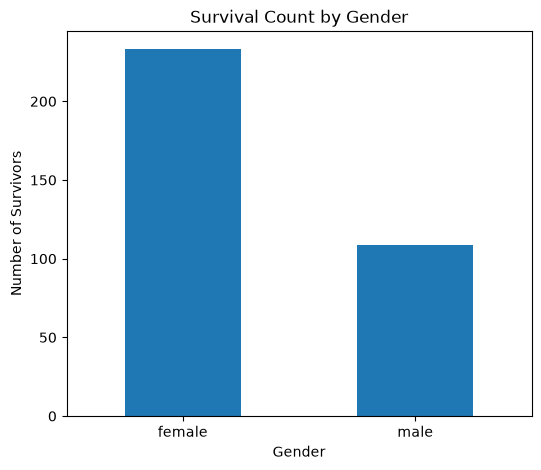

In [25]:
survival_by_gender = df[df["Survived"] == 1]["Sex"].value_counts()

plt.figure(figsize=(6,5))
survival_by_gender.plot(kind="bar")

plt.title("Survival Count by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Survivors")
plt.xticks(rotation=0)
plt.show()

## Observation

The bar chart clearly shows that female passengers had a much higher number of survivors than male passengers. This visual representation supports the earlier analysis, indicating that women had better survival chances during the Titanic disaster.

# Visualization 2: Survival by Passenger Class

This bar chart displays the number of survivors in each passenger class (First, Second, and Third Class). It helps visualize how passenger class influenced survival during the Titanic disaster.

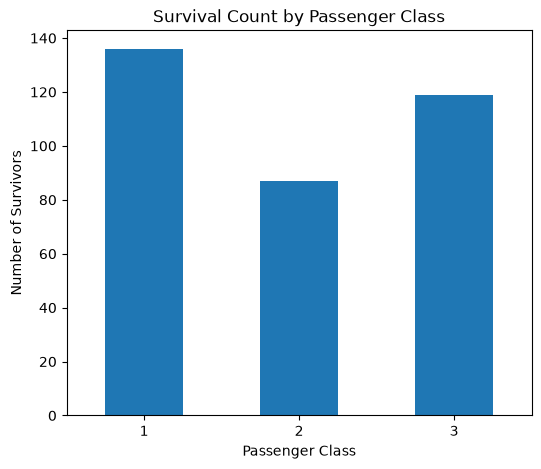

In [26]:
plt.figure(figsize=(6,5))

survival_by_class = df[df["Survived"] == 1]["Pclass"].value_counts().sort_index()

survival_by_class.plot(kind="bar")

plt.title("Survival Count by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Survivors")
plt.xticks(rotation=0)

plt.show()

## Observation

The bar chart shows that **First Class (Pclass 1)** had the highest number of survivors (**136**), followed by **Third Class (119)** and **Second Class (87)**. This indicates that First Class passengers had better survival opportunities than passengers in the other classes.

# Visualization 3: Distribution of Passenger Ages

This histogram shows the distribution of passengers' ages on the Titanic. It helps us understand the age composition of the passengers and identify the most common age groups.

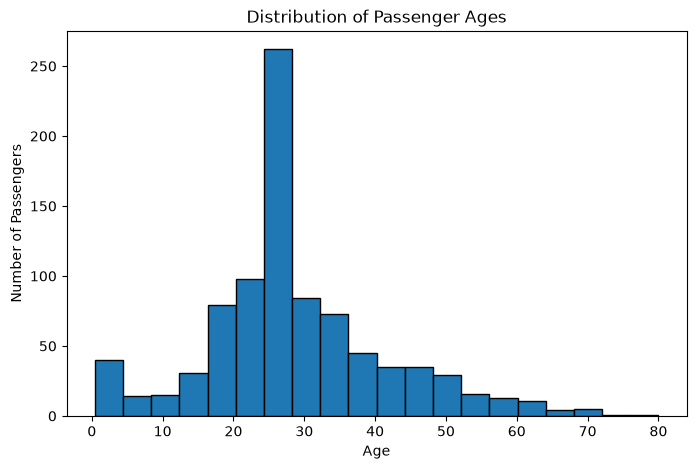

In [27]:
plt.figure(figsize=(8,5))

plt.hist(df["Age"], bins=20, edgecolor="black")

plt.title("Distribution of Passenger Ages")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

## Observation

The histogram shows that most passengers were between **20 and 40 years** of age. There were fewer children and senior passengers, indicating that the majority of people traveling on the Titanic were young adults and adults.

# Conclusion

The Titanic dataset was successfully analyzed after cleaning and handling all missing values. The analysis provided valuable insights into the survival patterns of passengers.

Key findings from the analysis include:

- Female passengers had a higher number of survivors than male passengers.
- First Class passengers had the highest number of survivors, indicating that passenger class influenced survival.
- Most survivors belonged to the Young Adult age group, while the fewest survivors were Senior passengers.
- The age distribution showed that most passengers on the Titanic were between 20 and 40 years old.

Overall, this analysis demonstrates how data cleaning, exploration, and visualization can be used to identify meaningful patterns and answer real-world questions. The project also provided practical experience with Python, Pandas, and Matplotlib for data analysis and visualization.